In [1]:
import os
import random
import numpy as np
import pandas as pd         
from glob import glob        
import shutil                
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms, models

import matplotlib.pyplot as plt

# Configuration 
class CFG:
    # Dataset
    DATASET_PATH = "/kaggle/input/prdb-rice/Original_Images"
    IMG_EXTS = (".jpg",)
    
    # Image settings
    IMG_SIZE = 224
    
    # Reproducibility
    SEED = 42
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    
    # SSL training
    SSL_BATCH = 64
    SSL_EPOCHS = 150
    SSL_LR = 3e-4
    SSL_WEIGHT_DECAY = 1e-4
    TEMP = 0.2
    PROJ_DIM = 128
    
    # Output
    OUT_DIR = "/kaggle/working/prdb_ssl"

# Create output directory if not exists
os.makedirs(CFG.OUT_DIR, exist_ok=True)

#Seed Setting 
def set_seed(seed=CFG.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()



In [2]:
# 1. Class Map for PRDB
CLASS_MAP = {
    "Aush": 0,
    "Beroi": 1,
    "BR-28": 2,
    "BR-29": 3,
    "Chinigura": 4,
    "Ghee Bhog": 5,
    "Katari Najir": 6,
    "Katari Siddho": 7,
    "Miniket": 8,
    "Swarna":9
}

PRDB_ROOT = "/kaggle/input/datasets/farhananuren/prdb-rice/Original_Images"

assert os.path.exists(PRDB_ROOT), "ERROR: PRDB dataset path does NOT exist!"
print("[INFO] Using PRDB root:", PRDB_ROOT)


# 2. Build Image Index
def build_index(root=PRDB_ROOT):
    rows = []
    for cls, lbl in CLASS_MAP.items():
        cls_folder = os.path.join(root, cls)
        for img_path in glob(os.path.join(cls_folder, "*")):
            if not img_path.lower().endswith(CFG.IMG_EXTS):
                continue
            rows.append({"image": img_path, "label": lbl, "cls": cls})
    df = pd.DataFrame(rows)
    print("Counts per class:\n", df["cls"].value_counts())
    return df

df_all = build_index(PRDB_ROOT)


[INFO] Using PRDB root: /kaggle/input/datasets/farhananuren/prdb-rice/Original_Images
Counts per class:
 cls
Aush             200
Beroi            200
BR-28            200
BR-29            200
Chinigura        200
Ghee Bhog        200
Katari Najir     200
Katari Siddho    200
Miniket          200
Swarna           200
Name: count, dtype: int64


In [3]:
import shutil
import os
from sklearn.model_selection import train_test_split

# Base directory for split data
base_split_dir = os.path.join(CFG.OUT_DIR, "split_data")
train_dir = os.path.join(base_split_dir, "train")
val_dir = os.path.join(base_split_dir, "val")
test_dir = os.path.join(base_split_dir, "test")

# Create base split directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

print("Splitting dataset into train (20%), val (10% of train), test (80%) for each class...")

for class_name, class_label in CLASS_MAP.items():
    # Filter images of current class
    class_df = df_all[df_all['cls'] == class_name]
    images_full_paths = class_df['image'].tolist()

    if not images_full_paths:
        print(f"[WARN] No images found for class {class_name}. Skipping.")
        continue

    # First split: train 20%, test 80%
    train_imgs, test_imgs = train_test_split(
        images_full_paths, test_size=0.80, random_state=CFG.SEED
    )

    # Second split: allocate 10% of training as validation
    val_size = 0.10  # 10% of training
    train_imgs, val_imgs = train_test_split(
        train_imgs, test_size=val_size, random_state=CFG.SEED
    )

    # Create class folders
    for d in [train_dir, val_dir, test_dir]:
        os.makedirs(os.path.join(d, class_name), exist_ok=True)

    # Copy files
    for img_path in train_imgs:
        shutil.copy(img_path, os.path.join(train_dir, class_name, os.path.basename(img_path)))
    for img_path in val_imgs:
        shutil.copy(img_path, os.path.join(val_dir, class_name, os.path.basename(img_path)))
    for img_path in test_imgs:
        shutil.copy(img_path, os.path.join(test_dir, class_name, os.path.basename(img_path)))

    print(f"{class_name}: Train={len(train_imgs)}, Val={len(val_imgs)}, Test={len(test_imgs)}")


Splitting dataset into train (20%), val (10% of train), test (80%) for each class...
Aush: Train=36, Val=4, Test=160
Beroi: Train=36, Val=4, Test=160
BR-28: Train=36, Val=4, Test=160
BR-29: Train=36, Val=4, Test=160
Chinigura: Train=36, Val=4, Test=160
Ghee Bhog: Train=36, Val=4, Test=160
Katari Najir: Train=36, Val=4, Test=160
Katari Siddho: Train=36, Val=4, Test=160
Miniket: Train=36, Val=4, Test=160
Swarna: Train=36, Val=4, Test=160


In [4]:
!pip install lightly


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 13.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Starting Training


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


epoch: 00, loss: 4.22087
epoch: 01, loss: 4.21047
epoch: 02, loss: 4.24603
epoch: 03, loss: 4.18087
epoch: 04, loss: 4.23274
epoch: 05, loss: 4.15160
epoch: 06, loss: 4.17775
epoch: 07, loss: 4.11292
epoch: 08, loss: 4.11781
epoch: 09, loss: 4.09685
epoch: 10, loss: 4.13630
epoch: 11, loss: 4.07567
epoch: 12, loss: 4.08213
epoch: 13, loss: 4.05962
epoch: 14, loss: 4.03777
epoch: 15, loss: 3.98216
epoch: 16, loss: 3.90857
epoch: 17, loss: 3.91922
epoch: 18, loss: 3.99939
epoch: 19, loss: 3.89631
epoch: 20, loss: 3.88039
epoch: 21, loss: 3.88561
epoch: 22, loss: 3.87328
epoch: 23, loss: 3.87373
epoch: 24, loss: 3.93760
epoch: 25, loss: 3.72642
epoch: 26, loss: 3.74323
epoch: 27, loss: 3.68232
epoch: 28, loss: 3.64019
epoch: 29, loss: 3.78842
epoch: 30, loss: 3.73832
epoch: 31, loss: 3.67053
epoch: 32, loss: 3.61847
epoch: 33, loss: 3.61293
epoch: 34, loss: 3.61060
epoch: 35, loss: 3.65473
epoch: 36, loss: 3.65100
epoch: 37, loss: 3.52124
epoch: 38, loss: 3.55133
epoch: 39, loss: 3.48557


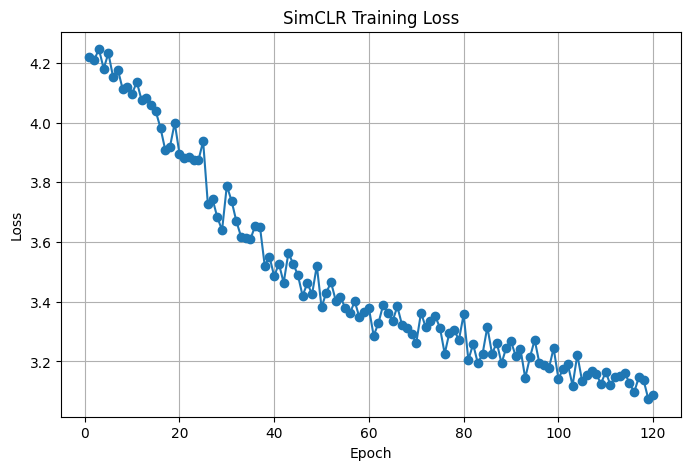

In [5]:
import torch
import torchvision
from torch import nn

from lightly.loss import NTXentLoss
from lightly.models.modules import SimCLRProjectionHead
from lightly.transforms.simclr_transform import SimCLRTransform
from lightly.data import LightlyDataset   # <-- added


class SimCLR(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        # DenseNet-121 output features = 1024
        self.projection_head = SimCLRProjectionHead(1024, 1024, 128)

    def forward(self, x):
        x = self.backbone(x).flatten(start_dim=1)
        z = self.projection_head(x)
        return z


densenet = torchvision.models.densenet121(weights=None)

backbone = nn.Sequential(
    densenet.features,
    nn.AdaptiveAvgPool2d((1, 1))  # global avg pool
)

model = SimCLR(backbone)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


transform = SimCLRTransform(input_size=224, gaussian_blur=0.0)

dataset = LightlyDataset(
    input_dir="/kaggle/working/prdb_ssl/split_data/train",
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    drop_last=True,
    num_workers=8,
)


criterion = NTXentLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.06)
all_losses = []

print("Starting Training")
for epoch in range(120):
    total_loss = 0
    for batch in dataloader:
        (x0, x1), _, _ = batch   # labels exist but ignored
        x0 = x0.to(device)
        x1 = x1.to(device)

        z0 = model(x0)
        z1 = model(x1)

        loss = criterion(z0, z1)
        total_loss += loss.detach()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    avg_loss = total_loss / len(dataloader)
    all_losses.append(avg_loss.cpu().item()) 
    print(f"epoch: {epoch:>02}, loss: {avg_loss:.5f}")


import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(all_losses)+1), all_losses, marker='o')
plt.title("SimCLR Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


****Linear Probe****

Epoch 1/80 Train Acc: 31.94%
Epoch 2/80 Train Acc: 46.67%
Epoch 3/80 Train Acc: 53.89%
Epoch 4/80 Train Acc: 62.78%
Epoch 5/80 Train Acc: 67.50%
Epoch 6/80 Train Acc: 68.89%
Epoch 7/80 Train Acc: 72.22%
Epoch 8/80 Train Acc: 72.78%
Epoch 9/80 Train Acc: 72.50%
Epoch 10/80 Train Acc: 72.22%
Epoch 11/80 Train Acc: 74.72%
Epoch 12/80 Train Acc: 76.67%
Epoch 13/80 Train Acc: 78.33%
Epoch 14/80 Train Acc: 76.39%
Epoch 15/80 Train Acc: 75.83%
Epoch 16/80 Train Acc: 79.17%
Epoch 17/80 Train Acc: 80.83%
Epoch 18/80 Train Acc: 77.78%
Epoch 19/80 Train Acc: 81.67%
Epoch 20/80 Train Acc: 83.06%
Epoch 21/80 Train Acc: 83.61%
Epoch 22/80 Train Acc: 81.39%
Epoch 23/80 Train Acc: 82.22%
Epoch 24/80 Train Acc: 81.94%
Epoch 25/80 Train Acc: 85.28%
Epoch 26/80 Train Acc: 82.78%
Epoch 27/80 Train Acc: 82.22%
Epoch 28/80 Train Acc: 82.78%
Epoch 29/80 Train Acc: 82.22%
Epoch 30/80 Train Acc: 83.06%
Epoch 31/80 Train Acc: 83.33%
Epoch 32/80 Train Acc: 86.67%
Epoch 33/80 Train Acc: 84.17%
Epoch 34/80 Train A

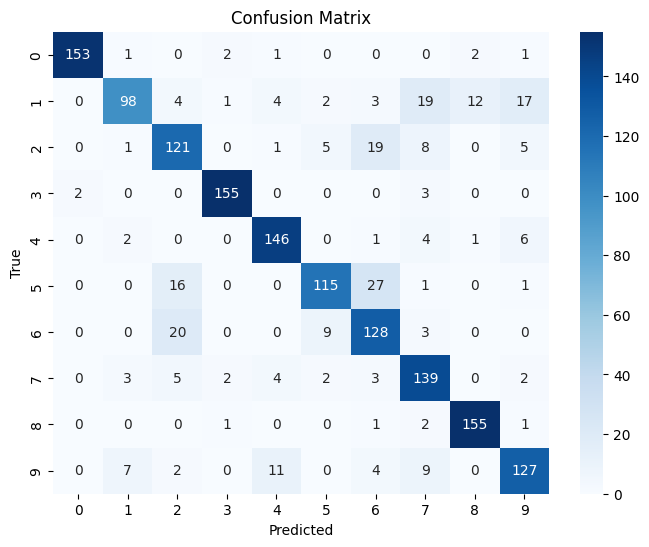

In [6]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = "cuda" if torch.cuda.is_available() else "cpu"

# Freeze backbone
for param in backbone.parameters():
    param.requires_grad = False

# Linear probe
class LinearProbe(nn.Module):
    def __init__(self, backbone, feature_dim=1024, num_classes=10):
        super().__init__()
        self.backbone = backbone
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        with torch.no_grad():
            features = self.backbone(x).flatten(1)
        return self.classifier(features)

model = LinearProbe(backbone, feature_dim=1024, num_classes=10).to(device)

# Data loaders
transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])

train_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/train", transform=transform),
    batch_size=32, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/test", transform=transform),
    batch_size=32, shuffle=False
)

# Training
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.classifier.parameters(), lr=0.01, momentum=0.9)
epochs = 80

for epoch in range(epochs):
    model.train()
    correct = total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
    print(f"Epoch {epoch+1}/{epochs} Train Acc: {100*correct/total:.2f}%")

# Evaluation
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    correct = total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"\nFINAL TEST ACCURACY: {100*correct/total:.2f}%")
print("\nClassification Report:\n", classification_report(all_labels, all_preds, digits=4))

# Confusion matrix as image
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


****MLP****

Epoch 1/80 Train Acc: 20.83%
Epoch 2/80 Train Acc: 40.28%
Epoch 3/80 Train Acc: 45.83%
Epoch 4/80 Train Acc: 48.33%
Epoch 5/80 Train Acc: 56.39%
Epoch 6/80 Train Acc: 55.00%
Epoch 7/80 Train Acc: 60.28%
Epoch 8/80 Train Acc: 58.89%
Epoch 9/80 Train Acc: 60.00%
Epoch 10/80 Train Acc: 67.22%
Epoch 11/80 Train Acc: 70.28%
Epoch 12/80 Train Acc: 67.78%
Epoch 13/80 Train Acc: 70.83%
Epoch 14/80 Train Acc: 70.83%
Epoch 15/80 Train Acc: 69.72%
Epoch 16/80 Train Acc: 66.94%
Epoch 17/80 Train Acc: 76.11%
Epoch 18/80 Train Acc: 73.06%
Epoch 19/80 Train Acc: 71.67%
Epoch 20/80 Train Acc: 76.39%
Epoch 21/80 Train Acc: 75.83%
Epoch 22/80 Train Acc: 77.78%
Epoch 23/80 Train Acc: 75.28%
Epoch 24/80 Train Acc: 76.39%
Epoch 25/80 Train Acc: 76.94%
Epoch 26/80 Train Acc: 80.00%
Epoch 27/80 Train Acc: 80.28%
Epoch 28/80 Train Acc: 77.78%
Epoch 29/80 Train Acc: 80.56%
Epoch 30/80 Train Acc: 78.33%
Epoch 31/80 Train Acc: 78.06%
Epoch 32/80 Train Acc: 83.06%
Epoch 33/80 Train Acc: 80.83%
Epoch 34/80 Train A

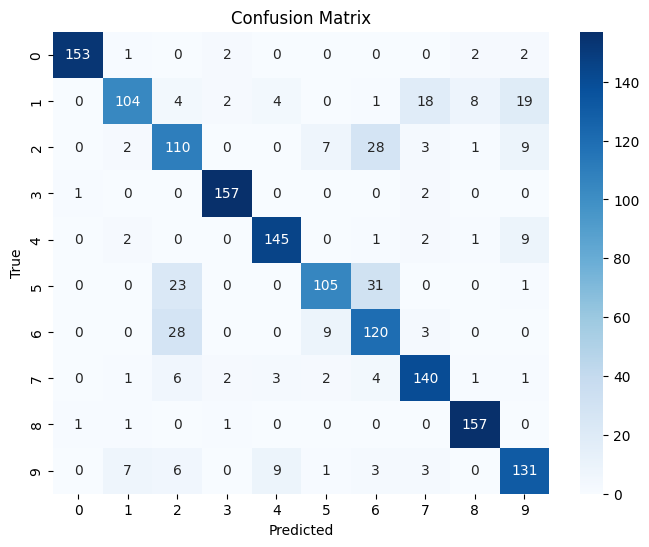

In [7]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = "cuda" if torch.cuda.is_available() else "cpu"

# Freeze backbone
for param in backbone.parameters():
    param.requires_grad = False

# MLP Probe 
class MLPProbe(nn.Module):
    def __init__(self, backbone, feature_dim=1024, hidden_dim=512, num_classes=10, dropout=0.5):
        super().__init__()
        self.backbone = backbone
        self.mlp = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        with torch.no_grad():  # freeze backbone
            features = self.backbone(x).flatten(1)
        return self.mlp(features)

model = MLPProbe(backbone, feature_dim=1024, hidden_dim=512, num_classes=10).to(device)

# Data 
transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])
train_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/train", transform=transform),
    batch_size=32, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/test", transform=transform),
    batch_size=32, shuffle=False
)

#Training 
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.mlp.parameters(), lr=0.01, momentum=0.9)
epochs = 80

for epoch in range(epochs):
    model.train()
    correct = total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
    print(f"Epoch {epoch+1}/{epochs} Train Acc: {100*correct/total:.2f}%")

#Evaluation 
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    correct = total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"\n FINAL TEST ACCURACY: {100*correct/total:.2f}%")
print("\nClassification Report:\n", classification_report(all_labels, all_preds, digits=4))

#Confusion Matrix as Image 
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


****SVM****


 SVM TEST ACCURACY: 84.25%

Classification Report:
               precision    recall  f1-score   support

           0     0.9812    0.9812    0.9812       160
           1     0.7518    0.6625    0.7043       160
           2     0.6906    0.7812    0.7331       160
           3     0.9744    0.9500    0.9620       160
           4     0.8869    0.9313    0.9085       160
           5     0.7964    0.8313    0.8135       160
           6     0.8175    0.7000    0.7542       160
           7     0.8000    0.8500    0.8242       160
           8     0.9277    0.9625    0.9448       160
           9     0.8052    0.7750    0.7898       160

    accuracy                         0.8425      1600
   macro avg     0.8432    0.8425    0.8416      1600
weighted avg     0.8432    0.8425    0.8416      1600



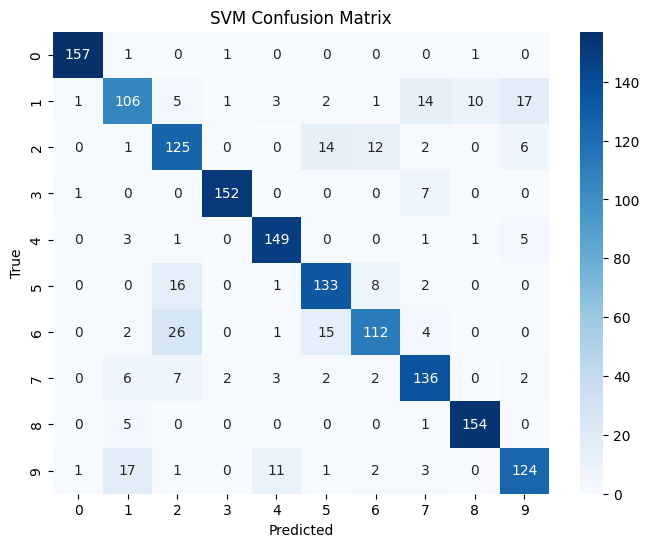

In [8]:
import torch
from torch import nn
from torchvision import datasets, transforms
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# ======= Feature Extraction 
# Freeze backbone
for param in backbone.parameters():
    param.requires_grad = False
backbone.eval()

def extract_features(dataloader):
    features_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            features = backbone(images).flatten(1)  # flatten
            features_list.append(features.cpu().numpy())
            labels_list.append(labels.numpy())
    X = np.concatenate(features_list, axis=0)
    y = np.concatenate(labels_list, axis=0)
    return X, y

# Data
transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])
train_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/train", transform=transform),
    batch_size=32, shuffle=False
)
test_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/test", transform=transform),
    batch_size=32, shuffle=False
)

# Extract features
X_train, y_train = extract_features(train_loader)
X_test, y_test = extract_features(test_loader)

# ======= SVM Training 
svm_clf = SVC(kernel='linear', C=1.0)
svm_clf.fit(X_train, y_train)

# ======= Evaluation 
y_pred = svm_clf.predict(X_test)

print(f"\n SVM TEST ACCURACY: {100*np.mean(y_pred==y_test):.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion Matrix as image
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("SVM Confusion Matrix")
plt.show()


****Decision Tree****



 Decision Tree TEST ACCURACY: 65.31%

Classification Report:
               precision    recall  f1-score   support

           0     0.9107    0.9563    0.9329       160
           1     0.5404    0.5437    0.5421       160
           2     0.3737    0.4437    0.4057       160
           3     0.9355    0.9062    0.9206       160
           4     0.6550    0.7000    0.6767       160
           5     0.5939    0.6125    0.6031       160
           6     0.4626    0.4250    0.4430       160
           7     0.5714    0.4750    0.5188       160
           8     0.9096    0.9437    0.9264       160
           9     0.5833    0.5250    0.5526       160

    accuracy                         0.6531      1600
   macro avg     0.6536    0.6531    0.6522      1600
weighted avg     0.6536    0.6531    0.6522      1600



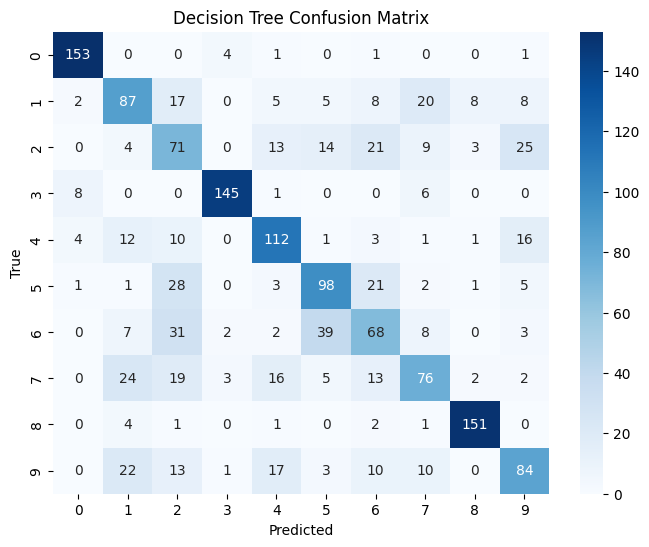

In [9]:
import torch
from torchvision import datasets, transforms
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# Freeze Backbone 
for param in backbone.parameters():
    param.requires_grad = False
backbone.eval()

# Feature Extraction 
def extract_features(dataloader):
    features_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            features = backbone(images).flatten(1)  # flatten to (batch, features)
            features_list.append(features.cpu().numpy())
            labels_list.append(labels.numpy())
    X = np.concatenate(features_list, axis=0)
    y = np.concatenate(labels_list, axis=0)
    return X, y

# Data Loaders 
transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])
train_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/train", transform=transform),
    batch_size=32, shuffle=False
)
test_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/test", transform=transform),
    batch_size=32, shuffle=False
)

# Extract features
X_train, y_train = extract_features(train_loader)
X_test, y_test = extract_features(test_loader)

# ======= Decision Tree ======= #
dt_clf = DecisionTreeClassifier(max_depth=15, random_state=42)
dt_clf.fit(X_train, y_train)

# ======= Evaluation ======= #
y_pred = dt_clf.predict(X_test)

print(f"\n Decision Tree TEST ACCURACY: {100*np.mean(y_pred==y_test):.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Decision Tree Confusion Matrix")
plt.show()
